# Tugas 1

## Missing Value

Missing value merupakan data yang memiliki nilai kosong atau `NaN`. Pada bagian ini dilakukan identifikasi dan penanganan missing value pada dataset.

In [1]:
import pandas as pd
path = "dataMissingValue.csv"
df = pd.read_csv(path)
df

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
2,C,High School,NaN,NaN,watermelon,NaN
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0
9,J,Middle School,NaN,NaN,avocado,35.0


### Menghitung Jumlah Missing Value

Perintah `df.isnull().sum()` digunakan untuk menghitung jumlah data yang hilang atau `NaN` pada setiap kolom.

In [2]:
df.isnull().sum()

Name            0
School Level    0
Blood Type      6
Age             3
Fav Fruit       2
Shoe Chart      2
dtype: int64

### Persentase Missing Value

Persentase missing value digunakan untuk mengetahui persentase data yang hilang pada setiap kolom. Informasi ini dapat digunakan untuk mengevaluasi apakah missing value perlu dihapus atau diisi kembali.

In [3]:
percent_missing = 100*df.isnull().mean()
percent_missing

Name             0.0
School Level     0.0
Blood Type      60.0
Age             30.0
Fav Fruit       20.0
Shoe Chart      20.0
dtype: float64

### Menghapus Baris yang Memiliki Missing Value

Fungsi `dropna(axis=0)` digunakan untuk menghapus baris yang memiliki missing value.

In [4]:
df.dropna(axis=0)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
4,E,Middle School,B,15.0,banana,37.0
7,H,High School,A,16.0,papaya,39.0


### Menghapus Kolom yang Memiliki Missing Value

Fungsi `dropna(axis=1)` digunakan untuk menghapus kolom yang memiliki missing value.


In [5]:
df.dropna(axis=1)

,Name,School Level
0,A,High School
1,B,High School
2,C,High School
3,D,High School
4,E,Middle School
5,F,Middle School
6,G,Middle School
7,H,High School
8,I,High School
9,J,Middle School


### Menggunakan Threshold

Parameter `thresh=5` berarti hanya baris yang memiliki minimal 5 nilai yang valid yang akan dipertahankan.

In [6]:
df.dropna(thresh=5)

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
4,E,Middle School,B,15.0,banana,37.0
6,G,Middle School,O,NaN,mango,36.0
7,H,High School,A,16.0,papaya,39.0


### Menghapus Missing Value pada Kolom Tertentu

Parameter `subset` digunakan untuk menentukan kolom yang menjadi acuan dalam pengecekan missing value. Pada contoh ini, baris yang memiliki missing value pada kolom `Age` akan dihapus.

In [7]:
df.dropna(subset=['Age'])

,Name,School Level,Blood Type,Age,Fav Fruit,Shoe Chart
0,A,High School,AB,15.0,apple,36.0
1,B,High School,NaN,17.0,banana,41.0
3,D,High School,NaN,16.0,NaN,38.0
4,E,Middle School,B,15.0,banana,37.0
5,F,Middle School,NaN,14.0,grapes,NaN
7,H,High School,A,16.0,papaya,39.0
8,I,High School,NaN,18.0,NaN,40.0


### Menghapus Kolom Blood Type

Kolom `Blood Type` dihapus menggunakan fungsi `drop()`.

In [8]:
df_drop = df.drop(columns = 'Blood Type')
df_drop

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,NaN
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,NaN
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


### Mengisi Missing Value dengan Mean

Fungsi `fillna()` digunakan untuk mengisi nilai yang kosong. Pada kolom `Age`, missing value diisi menggunakan nilai rata-rata atau mean.

In [9]:
df_filled = df_drop.copy()
df_filled['Age'] = df['Age'].fillna(df['Age'].mean())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,NaN
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,NaN
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


### Mengisi Missing Value dengan Median

Pada kolom `Shoe Chart`, missing value diisi menggunakan nilai median dari kolom tersebut.

In [10]:
df_filled['Shoe Chart'] = df['Shoe Chart'].fillna(df['Shoe Chart'].median())
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,NaN,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,NaN,40.0
9,J,Middle School,15.857143,avocado,35.0


### Mengisi Missing Value dengan Mode

Pada kolom `Fav Fruit`, missing value diisi menggunakan nilai mode, yaitu nilai yang paling sering muncul.

In [11]:
df_filled['Fav Fruit'] = df['Fav Fruit'].fillna(df['Fav Fruit'].mode().iloc[0])
df_filled

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.000000,apple,36.0
1,B,High School,17.000000,banana,41.0
2,C,High School,15.857143,watermelon,37.5
3,D,High School,16.000000,banana,38.0
4,E,Middle School,15.000000,banana,37.0
5,F,Middle School,14.000000,grapes,37.5
6,G,Middle School,15.857143,mango,36.0
7,H,High School,16.000000,papaya,39.0
8,I,High School,18.000000,banana,40.0
9,J,Middle School,15.857143,avocado,35.0


### Back Fill

Back fill atau `bfill()` digunakan untuk mengisi nilai yang kosong menggunakan nilai dari baris setelahnya.

In [12]:
df_filled2 = df_drop.copy()
df_filled2['Shoe Chart'] = df_filled2['Shoe Chart'].replace("", None).bfill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,NaN,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,NaN,40.0
9,J,Middle School,NaN,avocado,35.0


### Forward Fill

Forward fill atau `ffill()` digunakan untuk mengisi nilai yang kosong menggunakan nilai dari baris sebelumnya.

In [13]:
df_filled2['Fav Fruit'] = df_filled2['Fav Fruit'].replace("", None).ffill()
df_filled2

,Name,School Level,Age,Fav Fruit,Shoe Chart
0,A,High School,15.0,apple,36.0
1,B,High School,17.0,banana,41.0
2,C,High School,NaN,watermelon,38.0
3,D,High School,16.0,watermelon,38.0
4,E,Middle School,15.0,banana,37.0
5,F,Middle School,14.0,grapes,36.0
6,G,Middle School,NaN,mango,36.0
7,H,High School,16.0,papaya,39.0
8,I,High School,18.0,papaya,40.0
9,J,Middle School,NaN,avocado,35.0


## Outliers

Outliers adalah data yang memiliki nilai berbeda jauh dari sebagian besar data lainnya. Pada bagian ini, outliers dideteksi menggunakan boxplot dan metode Interquartile Range (IQR).

In [14]:
path = "weight-height_outlier.csv"
df2 = pd.read_csv(path)
df2

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


### Deteksi Outliers pada Height

Boxplot digunakan untuk mendeteksi outliers secara visual. Outliers dapat terlihat sebagai data yang berada di luar whiskers pada boxplot.

<Axes: ylabel='Height'>

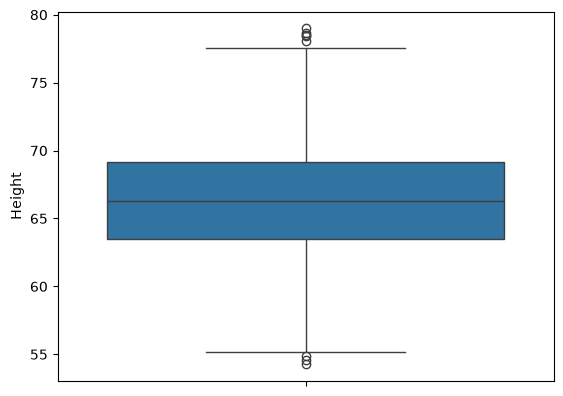

In [15]:
import seaborn as sns
sns.boxplot(df2['Height'])

<Axes: ylabel='Height'>

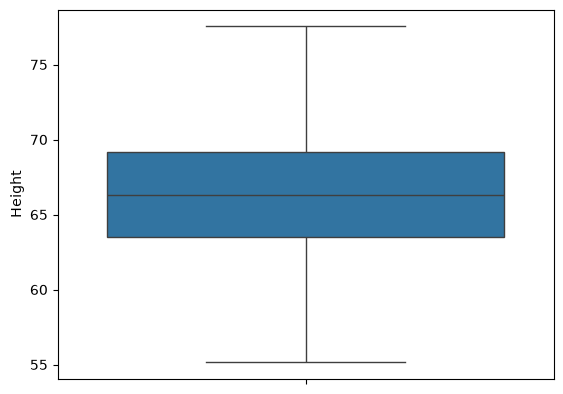

In [16]:
import numpy as np
# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Height'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Height'] >= lower_bound)
 & (df2['Height'] <= upper_bound)]
sns.boxplot(clean_data['Height'])

### Deteksi Outliers pada Weight

Selanjutnya dilakukan deteksi outliers pada kolom `Weight` menggunakan boxplot.

<Axes: ylabel='Weight'>

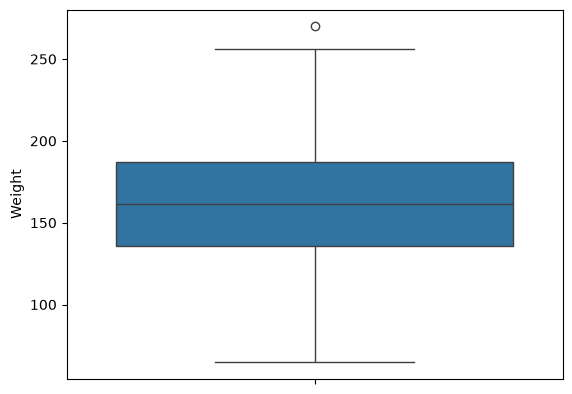

In [17]:
sns.boxplot(df2['Weight'])

<Axes: ylabel='Weight'>

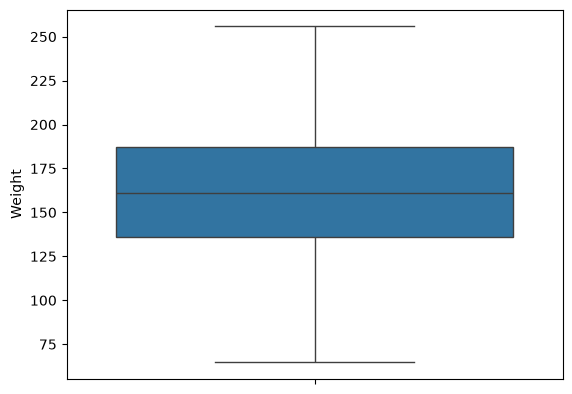

In [18]:
# Identifikasi Q1 Q3
q1, q3 = np.percentile(df2['Weight'], [25, 75])
# Hitung IQR
iqr = q3 - q1
# Cari lower dan upper bounds
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)
# Hapus outliers
clean_data = df2[(df2['Weight'] >= lower_bound)
 & (df2['Weight'] <= upper_bound)]
sns.boxplot(clean_data['Weight'])

### Deteksi Outliers dengan Matplotlib

Selain seaborn, outliers juga dapat divisualisasikan menggunakan matplotlib. Pada contoh ini, kolom `Weight` dan `Height` ditampilkan menggunakan boxplot.

In [20]:
import matplotlib.pyplot as plt

C:\Users\Brahmana P\AppData\Local\Temp\ipykernel_24228\282474575.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)
C:\Users\Brahmana P\AppData\Local\Temp\ipykernel_24228\282474575.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df2[col], vert=False)


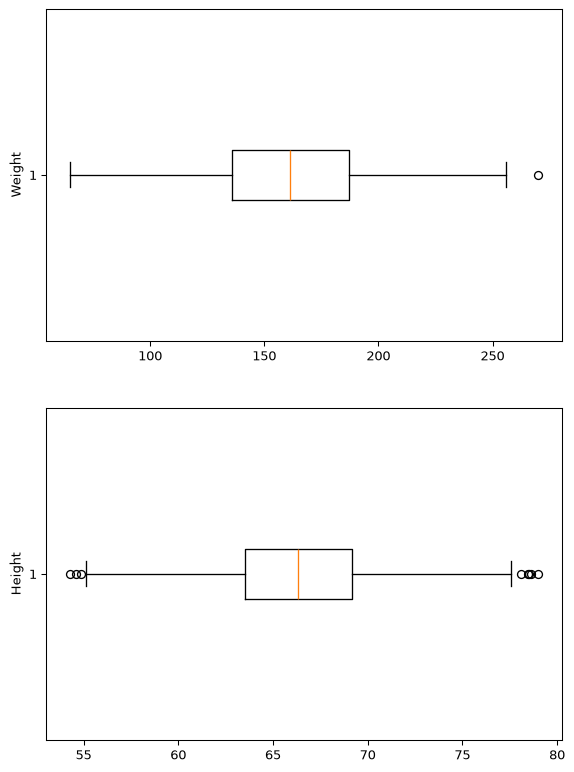

In [21]:
# Membuat daftar kolom yang ingin dianalisis, yaitu "Weight" dan "Height".
columns_to_plot = ['Weight', 'Height']
# Memastikan kolom ada di dataset
columns_to_plot = [col for col in columns_to_plot if col in df2.columns]
fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 5 * len(columns_to_plot)))
if len(columns_to_plot) == 1:
 axs = [axs]
for i, col in enumerate(columns_to_plot):
 axs[i].boxplot(df2[col], vert=False)
 axs[i].set_ylabel(col)
plt.show()

In [22]:
def remove_outliers_sequentially(df2, columns):
 df_cleaned = df2.copy()
 for col in columns:
  q1, q3 = np.percentile(df_cleaned[col], [25, 75])
  iqr = q3 - q1
  lower_bound = q1 - (1.5 * iqr)
  upper_bound = q3 + (1.5 * iqr)
  df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
 return df_cleaned

C:\Users\Brahmana P\AppData\Local\Temp\ipykernel_24228\3215983377.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)
C:\Users\Brahmana P\AppData\Local\Temp\ipykernel_24228\3215983377.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(clean_data[col], vert=False)


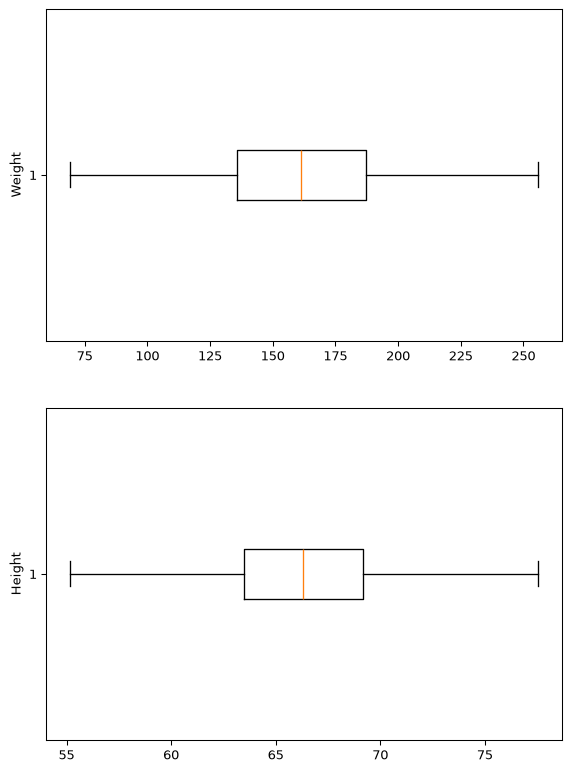

In [23]:
# Terapkan fungsi untuk menghapus outliers dari "Height" dan "Weight"
clean_data = remove_outliers_sequentially(df2, ['Height', 'Weight'])
# Plot boxplots setelah menghapus outliers
columns_to_plot = ['Weight', 'Height']
fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 5 * len(columns_to_plot)))
if len(columns_to_plot) == 1:
 axs = [axs]
for i, col in enumerate(columns_to_plot):
 axs[i].boxplot(clean_data[col], vert=False)
 axs[i].set_ylabel(col)
plt.show()

## Min-Max Scaling

Min-Max Scaling digunakan untuk mengubah nilai numerik ke dalam rentang tertentu. Pada contoh modul digunakan rentang 0 sampai 1.

In [24]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

In [25]:
# Memisahkan kolom numerik dan non-numerik
numeric_cols = clean_data.select_dtypes(include=[np.number]).columns
non_numeric_cols = clean_data.select_dtypes(exclude=[np.number]).columns
rescaled_numeric = scaler.fit_transform(clean_data[numeric_cols])
rescaled_numeric[:]

array([[0.83480376, 0.92524773],
       [0.6086688 , 0.49939825],
       [0.84654949, 0.76925146],
       ...,
       [0.38928431, 0.31834619],
       [0.61993463, 0.50764944],
       [0.30339752, 0.23901104]], shape=(9992, 2))

In [26]:
# Konversi kembali hasil scaling ke DataFrame
rescaled_df = pd.DataFrame(rescaled_numeric, columns=numeric_cols, index=clean_data.index)
# Gabungkan kembali dengan kolom non-numerik tanpa mengubah jumlah baris
final_df = pd.concat([clean_data[non_numeric_cols], rescaled_df], axis=1)
final_df

,Gender,Height,Weight
0,Male,0.834804,0.925248
1,Male,0.608669,0.499398
2,Male,0.846549,0.769251
3,Male,0.740332,0.808322
4,Male,0.657774,0.735053
...,...,...,...
9995,Female,0.492177,0.362771
9996,Female,0.532113,0.545189
9997,Female,0.389284,0.318346
9998,Female,0.619935,0.507649


# Tugas 2 — Handling Missing Value

Pada tugas ini dilakukan handling missing value pada dataset `Titanic-Dataset.csv`. Setelah seluruh missing value ditangani, dilakukan pengecekan menggunakan `df.isnull().sum()`.

In [2]:
import pandas as pd
path = "Titanic-Dataset.csv"
df = pd.read_csv(path)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Identifikasi Missing Value

Langkah pertama adalah menghitung jumlah missing value pada setiap kolom menggunakan `df.isnull().sum()`. Hasil ini digunakan untuk mengetahui kolom yang perlu ditangani.

In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Strategi Handling Missing Value

Berdasarkan hasil identifikasi, terdapat missing value pada kolom `Age`, `Cabin`, dan `Embarked`.

Kolom `Age` akan diisi menggunakan nilai mean karena merupakan data numerik. Kolom `Embarked` akan diisi menggunakan mode karena merupakan data kategorikal. Kolom `Cabin` akan dihapus karena memiliki jumlah missing value yang sangat banyak dibandingkan jumlah keseluruhan data.

In [4]:
df = df.drop(columns = 'Cabin')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


## Mengisi Missing Value pada Age

Kolom `Age` merupakan data numerik. Missing value pada kolom ini diisi menggunakan nilai mean atau rata-rata dari data `Age` yang tersedia.

In [6]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


## Mengisi Missing Value pada Embarked

Kolom `Embarked` merupakan data kategorikal. Oleh karena itu, missing value pada kolom ini diisi menggunakan nilai mode, yaitu nilai yang paling sering muncul.

In [7]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode().iloc[0])
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C


## Pemeriksaan Missing Value Setelah Handling

Setelah seluruh missing value ditangani, dilakukan pengecekan kembali menggunakan `df.isnull().sum()` untuk memastikan bahwa tidak terdapat lagi missing value pada dataset.

In [8]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Kesimpulan

Berdasarkan hasil pemeriksaan akhir, seluruh missing value pada dataset Titanic telah ditangani. Missing value pada kolom `Age` diisi menggunakan nilai mean, sedangkan missing value pada kolom `Embarked` diisi menggunakan nilai mode. Kolom `Cabin` dihapus karena memiliki jumlah missing value yang sangat banyak.

Hasil `df.isnull().sum()` menunjukkan bahwa seluruh kolom yang tersisa memiliki nilai missing sebesar 0. Dengan demikian, dataset telah terbebas dari missing value.

# Tugas 3 — Handling Outliers

Pada tugas ini dilakukan handling outliers pada dataset `diabetes.csv`. Tiga kolom yang dipilih untuk deteksi outliers adalah `Glucose`, `BloodPressure`, dan `BMI`.

Deteksi outliers dilakukan menggunakan boxplot dari Matplotlib dan metode Interquartile Range (IQR).

In [9]:
import pandas as pd
path = "diabetes.csv"
df = pd.read_csv(path)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## Visualisasi Outliers

Matplotlib digunakan untuk membuat boxplot sehingga distribusi data dan kemungkinan outliers dapat diamati secara visual.

In [10]:
import matplotlib.pyplot as plt

## Deteksi Outliers pada Tiga Kolom

Boxplot digunakan untuk melihat distribusi data pada `Glucose`, `BloodPressure`, dan `BMI`. Data yang berada jauh di luar distribusi utama dapat menjadi indikasi adanya outliers.

C:\Users\Brahmana P\AppData\Local\Temp\ipykernel_20664\2975935136.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df[col], vert=False)
C:\Users\Brahmana P\AppData\Local\Temp\ipykernel_20664\2975935136.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df[col], vert=False)
C:\Users\Brahmana P\AppData\Local\Temp\ipykernel_20664\2975935136.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df[col], vert=False)


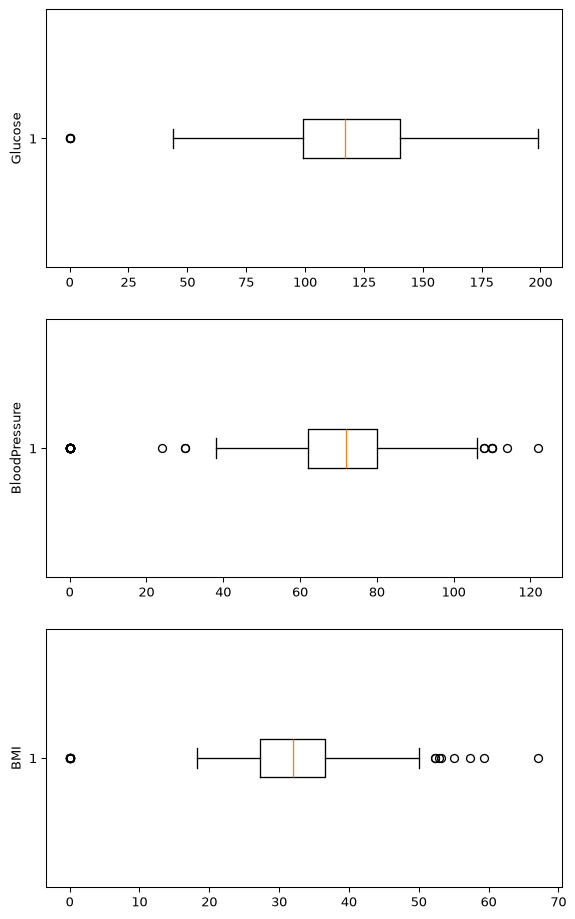

In [11]:
columns_to_plot = ['Glucose', 'BloodPressure', 'BMI']
fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 12))

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

## Perhitungan IQR

Interquartile Range (IQR) digunakan untuk menentukan batas bawah dan batas atas dalam mendeteksi outliers.

Rumus yang digunakan adalah:

- IQR = Q3 - Q1
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Data yang berada di luar batas tersebut dianggap sebagai outliers.

In [12]:
q1 = df['Glucose'].quantile(0.25)
q3 = df['Glucose'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

print("Glucose")
print("Q1 =", q1)
print("Q3 =", q3)
print("IQR =", iqr)
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

Glucose
Q1 = 99.0
Q3 = 140.25
IQR = 41.25
Lower Bound = 37.125
Upper Bound = 202.125


In [13]:
q1 = df['BloodPressure'].quantile(0.25)
q3 = df['BloodPressure'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

print("BloodPressure")
print("Q1 =", q1)
print("Q3 =", q3)
print("IQR =", iqr)
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

BloodPressure
Q1 = 62.0
Q3 = 80.0
IQR = 18.0
Lower Bound = 35.0
Upper Bound = 107.0


In [14]:
q1 = df['BMI'].quantile(0.25)
q3 = df['BMI'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

print("BMI")
print("Q1 =", q1)
print("Q3 =", q3)
print("IQR =", iqr)
print("Lower Bound =", lower_bound)
print("Upper Bound =", upper_bound)

BMI
Q1 = 27.3
Q3 = 36.6
IQR = 9.3
Lower Bound = 13.35
Upper Bound = 50.550000000000004


## Handling Outliers

Data yang berada di luar lower bound dan upper bound pada masing-masing kolom akan dihapus. Proses dilakukan secara berurutan pada `Glucose`, `BloodPressure`, dan `BMI`.

In [15]:
df_clean = df.copy()

for col in ['Glucose', 'BloodPressure', 'BMI']:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

df_clean

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## Boxplot Setelah Handling Outliers

Setelah proses handling dilakukan, boxplot dibuat kembali untuk melihat perubahan distribusi data pada `Glucose`, `BloodPressure`, dan `BMI`.

C:\Users\Brahmana P\AppData\Local\Temp\ipykernel_20664\1059671587.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df_clean[col], vert=False)
C:\Users\Brahmana P\AppData\Local\Temp\ipykernel_20664\1059671587.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df_clean[col], vert=False)
C:\Users\Brahmana P\AppData\Local\Temp\ipykernel_20664\1059671587.py:5: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axs[i].boxplot(df_clean[col], vert=False)


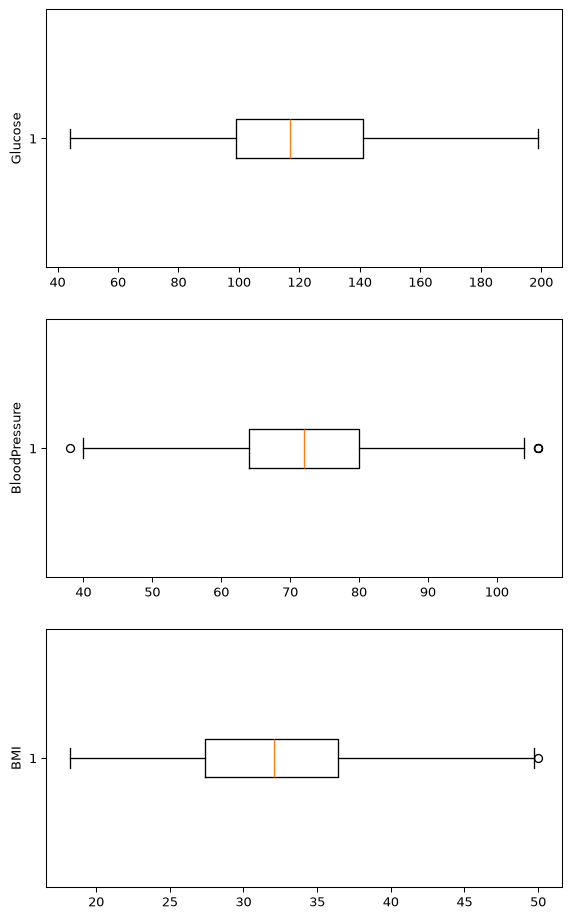

In [16]:
columns_to_plot = ['Glucose', 'BloodPressure', 'BMI']
fig, axs = plt.subplots(len(columns_to_plot), 1, dpi=95, figsize=(7, 12))

for i, col in enumerate(columns_to_plot):
    axs[i].boxplot(df_clean[col], vert=False)
    axs[i].set_ylabel(col)

plt.show()

## Kesimpulan

Pada tugas ini dilakukan deteksi dan handling outliers pada tiga kolom dataset `diabetes.csv`, yaitu `Glucose`, `BloodPressure`, dan `BMI`.

Deteksi outliers dilakukan menggunakan boxplot dengan Matplotlib dan metode Interquartile Range (IQR). Batas outliers ditentukan berdasarkan nilai Q1 dan Q3, kemudian dihitung lower bound dan upper bound menggunakan faktor 1.5 × IQR.

Data yang berada di luar batas tersebut dihapus. Setelah proses handling selesai, boxplot kembali dibuat untuk melihat kondisi data setelah outliers ditangani.